In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

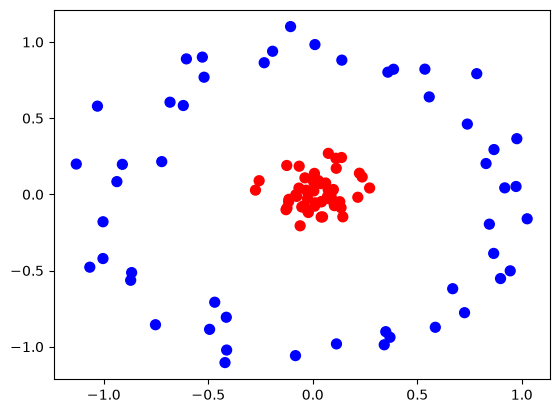

In [2]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [4]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [5]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.35

In [6]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\mohdr\AppData\Local\Temp\ipykernel_17916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


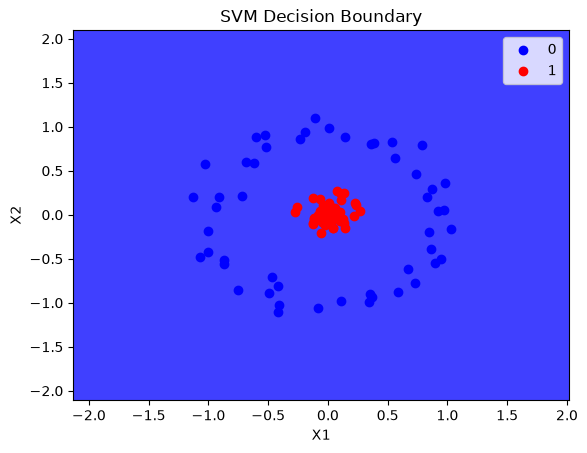

In [7]:
plot_decision_boundary(X, y, classifier)

In [8]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

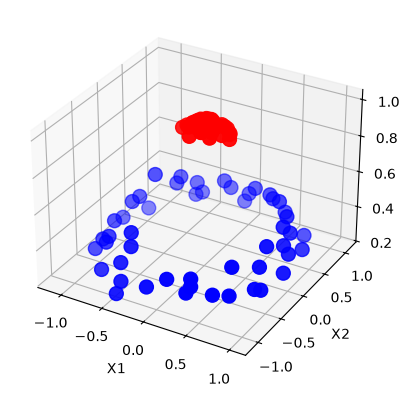

In [9]:
plot_3d_plot(X,y)

In [10]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\mohdr\AppData\Local\Temp\ipykernel_17916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


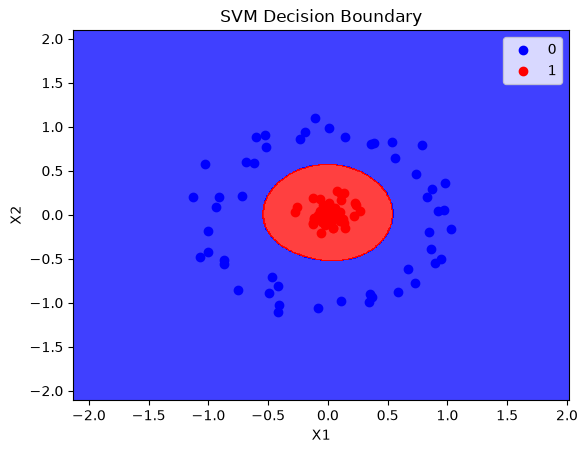

In [12]:
plot_decision_boundary(X, y, rbf_classifier)

In [13]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [14]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\mohdr\AppData\Local\Temp\ipykernel_17916\2718072598.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


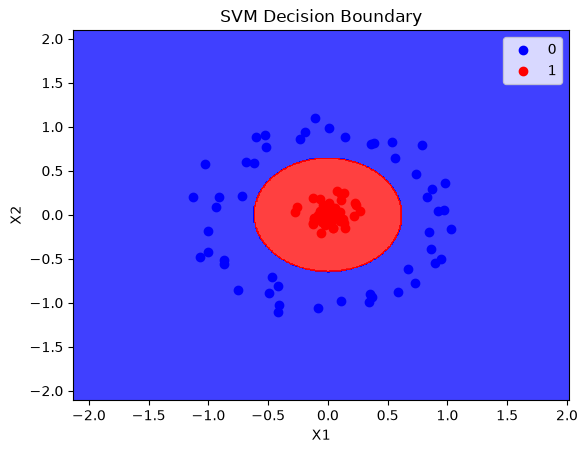

In [15]:
plot_decision_boundary(X, y, poly_classifier)

In [16]:
X

array([[ 0.01260777, -0.05569732],
       [ 0.55728578,  0.63967604],
       [ 0.07356573,  0.0321367 ],
       [ 0.03996426, -0.04939424],
       [ 0.12927738, -0.04823166],
       [ 0.97640212,  0.36550231],
       [-0.06488426,  0.18474628],
       [ 0.89838996, -0.5526833 ],
       [ 0.78459418,  0.79217   ],
       [-0.04147308, -0.07381753],
       [ 0.22336475,  0.13871611],
       [-0.06037637, -0.20636993],
       [ 0.10342124, -0.07417243],
       [-1.00361682, -0.42126078],
       [-0.91084913,  0.19691826],
       [ 0.00717469,  0.09412251],
       [-0.52820714,  0.90092105],
       [ 0.35938539,  0.802055  ],
       [ 0.00463606,  0.07966993],
       [ 0.8656547 , -0.38765123],
       [-0.12430053,  0.18956663],
       [-0.41196759, -1.02189794],
       [-0.68285365,  0.60487813],
       [-0.93711672,  0.08359106],
       [ 0.38643572,  0.82106135],
       [-0.23221164,  0.86402345],
       [-0.05256326, -0.08285247],
       [ 0.72625301, -0.77667076],
       [ 0.00505511,

In [17]:
np.exp(-(X**2)).sum(1)

array([1.99674367, 1.39722194, 1.99357047, 1.99596732, 1.98110265,
       1.26039035, 1.96224359, 1.18293325, 1.07423024, 1.99284725,
       1.93227413, 1.95466694, 1.9838746 , 1.20261711, 1.39816901,
       1.9911286 , 1.20065857, 1.40439454, 1.99365131, 1.33314251,
       1.94937063, 1.19585011, 1.32091362, 1.40857217, 1.37087623,
       1.42151119, 1.99039989, 1.13716039, 1.99947332, 1.40833283,
       1.14739538, 1.2588181 , 1.44098164, 1.13383655, 1.92833403,
       1.97615785, 1.19578996, 1.99239113, 1.32887757, 1.9765296 ,
       1.92691428, 1.39315486, 1.98928683, 1.3802161 , 1.9869409 ,
       1.54818988, 1.93323709, 1.11627157, 1.31930967, 1.26683103,
       1.98596865, 1.99065557, 1.06127053, 1.97412953, 1.45211716,
       1.36875407, 1.31673723, 1.28617916, 1.97709673, 1.98451362,
       1.17616412, 1.99823799, 1.92688706, 1.24016188, 1.33351003,
       1.99351405, 1.99115898, 1.99392209, 1.32368361, 1.28702025,
       1.92439399, 1.95422899, 1.95856456, 1.38869038, 1.23922

In [18]:
X_new=np.exp(-(X**2))

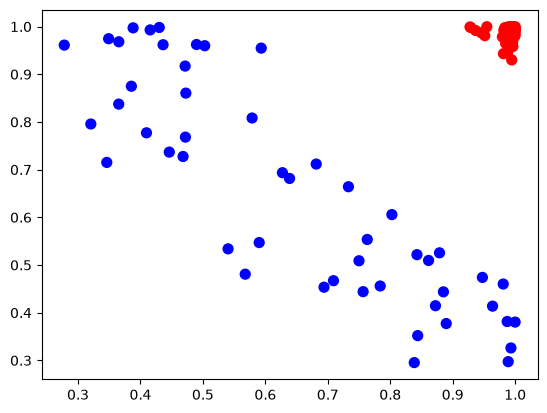

In [19]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')